In [1]:
MODEL_NAME = "vgg19"
OPTIMIZER_NAME = "adam"
DATASET_NAME = "cifar10"

In [2]:
import os
import json
import argparse

import warnings
warnings.filterwarnings('ignore')

from tqdm import tqdm
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from analyze.metrics import compute_cka, compute_energy, compute_weight_norm
from models import build_resnet, build_vgg, build_mlp

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

result_path = f"results/{MODEL_NAME}_{DATASET_NAME}_{OPTIMIZER_NAME}/"
fig_path = os.path.join(result_path, "figures")
os.makedirs("figures", exist_ok=True)
os.makedirs(fig_path, exist_ok=True)

checkpoints_path = os.path.join(result_path, "checkpoints")
checkpoints = os.listdir(checkpoints_path)
checkpoints.sort(key=lambda x: int(x.split(".")[0][5:]))

num_epochs = int(checkpoints[-1].split(".")[0][5:])
print(f"Found {num_epochs} checkpoints")

Using device: cuda
Found 200 checkpoints


In [3]:
if MODEL_NAME.startswith("resnet"):
    model = build_resnet(MODEL_NAME, 10)
elif MODEL_NAME.startswith("vgg"):
    model = build_vgg(MODEL_NAME, 10)
elif MODEL_NAME.startswith("mlp"):
    model = build_mlp(MODEL_NAME, 10)
else:
    raise ValueError(f"Unknown model name: {MODEL_NAME}")
layer_names = model.get_layer_names(); print(len(layer_names), layer_names)

label_names = []
if MODEL_NAME.startswith("resnet"):
    for i, name in enumerate(layer_names):
        label_names.append(f"conv_{i+1}")
elif MODEL_NAME.startswith("vgg"):
    for name in layer_names:
        if "conv_blocks" in name:
            label_names.append(f"conv_{int(name.split('.')[1]) + 1}")
        if "classifier" in name:
            label_names.append(f"linear_{int(name.split('.')[1]) + 1}")
elif MODEL_NAME.startswith("mlp"):
    for i, name in enumerate(layer_names):
        label_names.append(f"linear_{i+1}")

19 ['conv_blocks.0.0', 'conv_blocks.1.0', 'conv_blocks.3.0', 'conv_blocks.4.0', 'conv_blocks.6.0', 'conv_blocks.7.0', 'conv_blocks.8.0', 'conv_blocks.9.0', 'conv_blocks.11.0', 'conv_blocks.12.0', 'conv_blocks.13.0', 'conv_blocks.14.0', 'conv_blocks.16.0', 'conv_blocks.17.0', 'conv_blocks.18.0', 'conv_blocks.19.0', 'classifier.0.0', 'classifier.1.0', 'classifier.2.0']


## Loss and Accuracy Curves

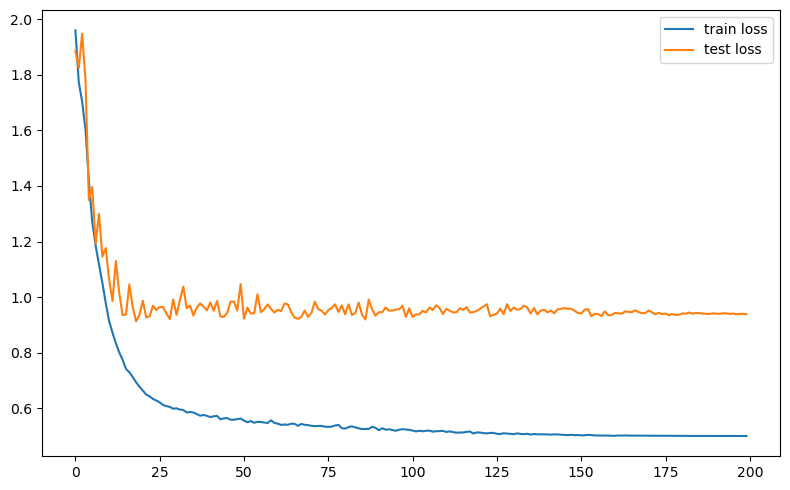

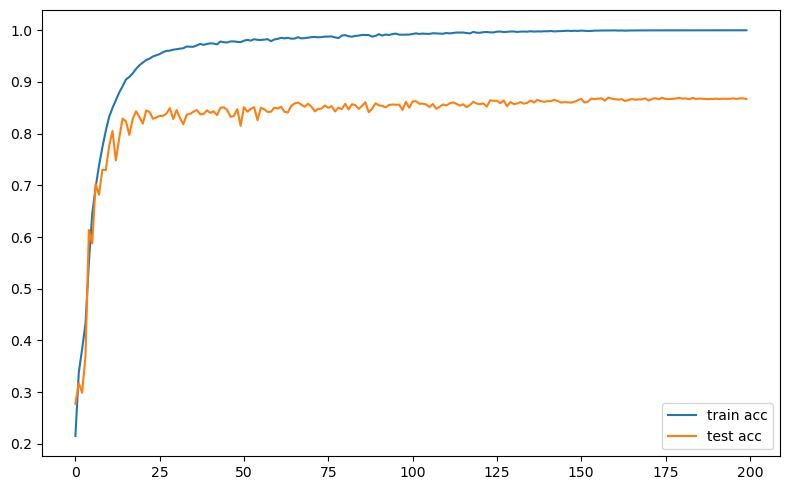

In [4]:
checkpoint = torch.load(os.path.join(checkpoints_path, f"epoch{num_epochs}.pt"), map_location='cpu')

plt.figure(figsize=(8, 5))
plt.plot(checkpoint["train_history"]['loss'], label="train loss")
plt.plot(checkpoint["test_history"]['loss'], label="test loss")
plt.legend(title="")
plt.tight_layout()
plt.savefig(f"{fig_path}/loss.png")

plt.figure(figsize=(8, 5))
plt.plot(checkpoint["train_history"]['accuracy'], label="train acc")
plt.plot(checkpoint["test_history"]['accuracy'], label="test acc")
plt.legend(title="")
plt.tight_layout()
plt.savefig(f"{fig_path}/accuracy.png")


## Tunnel Analysis

95% Tunnel Starts at conv_7 layer 5 (21.1%)
98% Tunnel Starts at conv_8 layer 6 (26.3%)


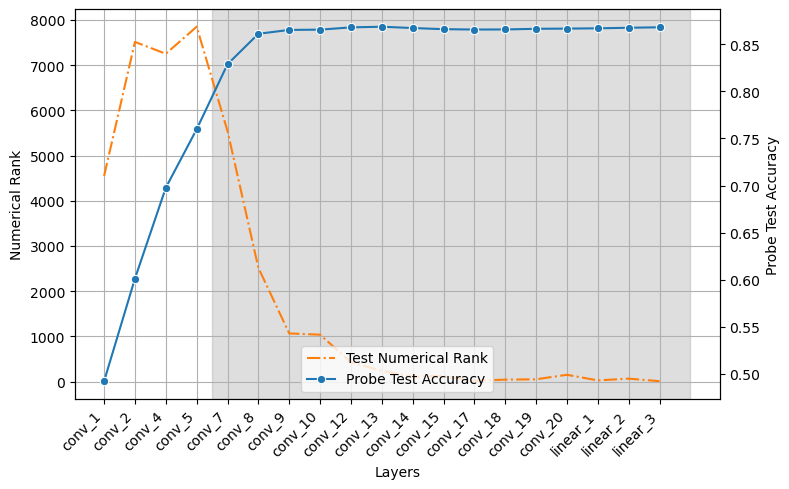

In [5]:
analysis = json.load(open(os.path.join(result_path, "analysis", f"epoch{num_epochs}", "analysis.json"), "r"))

final_acc = checkpoint["test_history"]['accuracy'][-1]
threshold_95 = 0.95 * final_acc
tunnel_95 = next((i for i, a in enumerate(analysis["probe_test_acc"]) if a >= threshold_95), len(analysis["layers"]) - 1)
threshold_98 = 0.98 * final_acc
tunnel_98 = next((i for i, a in enumerate(analysis["probe_test_acc"]) if a >= threshold_98), len(analysis["layers"]) - 1)

print("95% Tunnel Starts at", label_names[tunnel_95], f"layer {tunnel_95 + 1} ({tunnel_95/len(label_names)*100:.1f}%)")
print("98% Tunnel Starts at", label_names[tunnel_98], f"layer {tunnel_98 + 1} ({tunnel_98/len(label_names)*100:.1f}%)")

fig, ax1 = plt.subplots(figsize=(8, 5))
ax2 = ax1.twinx() 

ax1.axvspan(tunnel_95 - 0.5, len(label_names),
            alpha=0.25, color="tab:gray")

sns.lineplot(analysis["test_numerical_rank"], linestyle='dashdot', color="tab:orange", ax=ax1, label="Test Numerical Rank", legend=False)
ax1.set_xlabel('Layers')
ax1.set_xticks(range(len(label_names)), labels=label_names, rotation=45, ha='right')
ax1.tick_params(axis='x', rotation=45)
ax1.set_ylabel('Numerical Rank')

sns.lineplot(analysis["probe_test_acc"], marker='o', color="tab:blue", ax=ax2, label="Probe Test Accuracy", legend=False)
ax2.set_ylabel('Probe Test Accuracy')

fig.tight_layout()
ax1.grid(True)

handles1, labels1 = ax1.get_legend_handles_labels()
handles2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(handles1 + handles2, labels1 + labels2, title="", loc="lower center")
plt.tight_layout()
plt.savefig(f"{fig_path}/tunnel_analysis.png")

## Inter / Intra Variance

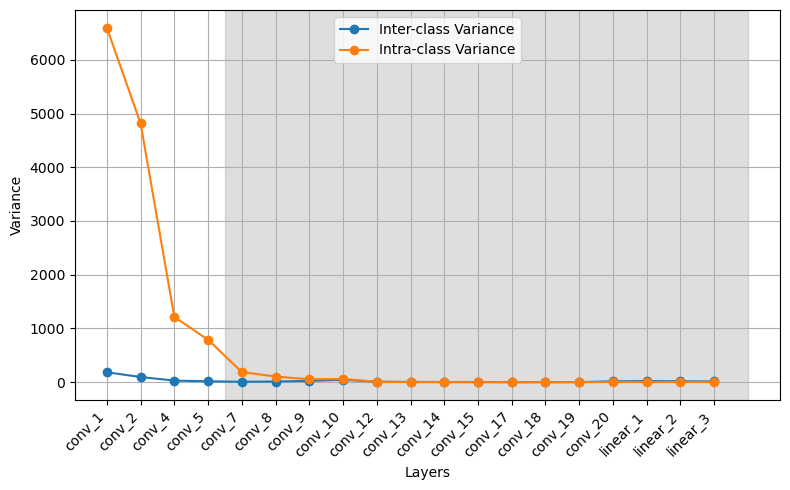

In [6]:
inters, intras = [], []
for inter, intra in analysis["test_variance"]:
    inters.append(inter)
    intras.append(intra)

fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

ax.axvspan(tunnel_95 - 0.5, len(label_names),
            alpha=0.25, color="tab:gray")

plt.plot(inters, label="Inter-class Variance", marker='o')
plt.plot(intras, label="Intra-class Variance", marker='o')

ax.set_xlabel('Layers')
ax.set_xticks(range(len(label_names)), labels=label_names, rotation=45, ha='right')
ax.set_ylabel('Variance')
plt.legend(title="")
plt.grid()
plt.tight_layout()
plt.savefig(f"{fig_path}/variance.png")

## CKA

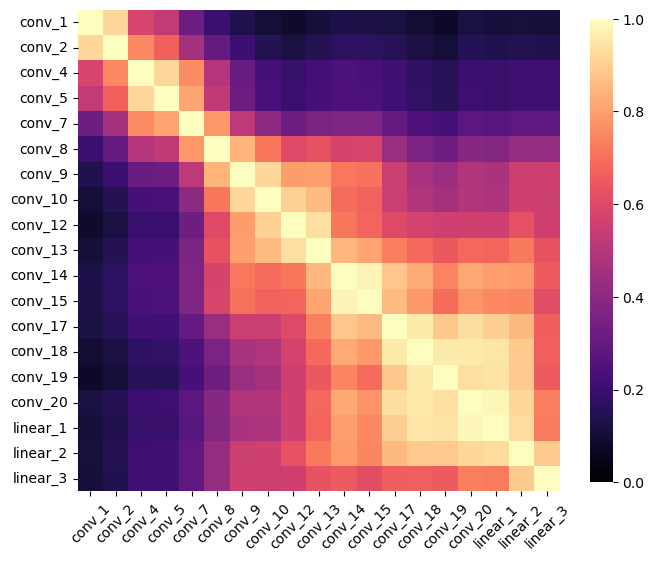

In [7]:
ckas = np.zeros((len(layer_names), len(layer_names)))

# Pre-load all feature tensors to avoid repeated disk I/O
all_feats = {}
for layer_name in layer_names:
    all_feats[layer_name] = torch.load(os.path.join(result_path, "analysis", f"epoch{num_epochs}", "features", f"test_feats_{layer_name}.pt"), map_location='cpu')

for i, layer1 in enumerate(layer_names):
    feat1 = all_feats[layer1] # Retrieve pre-loaded feature
    for j, layer2 in enumerate(layer_names):
        if j < i:
            continue

        feat2 = all_feats[layer2] # Retrieve pre-loaded feature
        cka_value = compute_cka(feat1, feat2, device)
        ckas[i, j] = cka_value
        ckas[j, i] = cka_value

del all_feats
if torch.cuda.is_available():
    torch.cuda.empty_cache()
import gc
gc.collect()

fig, ax = plt.subplots(figsize=(7, 7))

sns.heatmap(
    ckas, ax=ax, cmap="magma", vmin=0, vmax=1,
    square=True, cbar=True, cbar_kws={'shrink': 0.7},
    xticklabels=label_names, yticklabels=label_names
)
ax.tick_params(axis="x", rotation=45)
ax.tick_params(axis="y", rotation=0)
plt.tight_layout()
plt.show()


## Tunnel Development

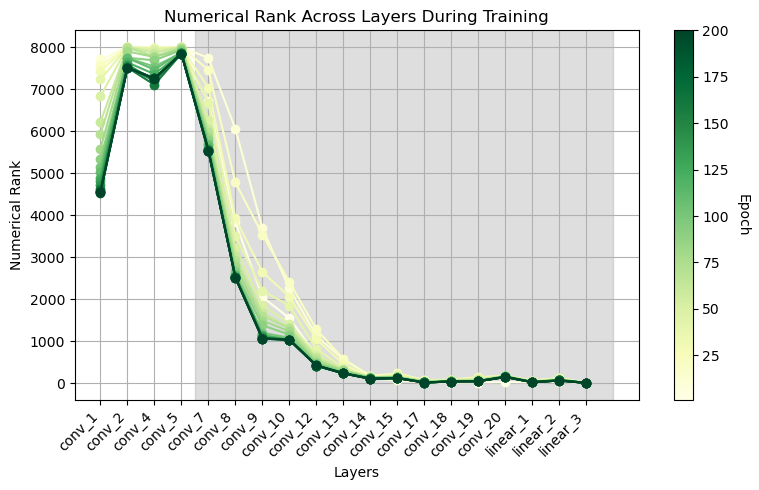

In [8]:
ranks = []

for epoch in range(0, num_epochs + 1, 10):
    ep = 1 if epoch == 0 else epoch
    with open(os.path.join(result_path, f"analysis/epoch{ep}/analysis.json"), "r") as f:
        analysis = json.load(f)
    rank = analysis["test_numerical_rank"]
    ranks.append(rank)

from matplotlib.colors import Normalize
fig = plt.figure(figsize=(8, 5))
ax = fig.add_subplot(111)

norm = Normalize(vmin=1, vmax=num_epochs)
cmap = plt.get_cmap("YlGn")

ax.axvspan(tunnel_95 - 0.5, len(label_names),
            alpha=0.25, color="tab:gray")
for i, rank in enumerate(ranks):
    ep = 1 if i == 0 else (i) * 10
    color = cmap(norm(ep))
    plt.plot(rank, color=color, marker='o', label=f"Epoch {ep}")

sm = plt.cm.ScalarMappable(cmap=cmap, norm=norm)
sm.set_array([])
cbar = plt.colorbar(sm, ax=ax)
cbar.set_label('Epoch', rotation=270, labelpad=15)
plt.xticks(range(len(label_names)), labels=label_names, rotation=45, ha='right')
plt.xlabel("Layers")
plt.ylabel("Numerical Rank")
plt.title("Numerical Rank Across Layers During Training")
plt.grid()
plt.tight_layout()
plt.savefig(f"{fig_path}/ranks_per_epoch.png")

## Weight Differences per Epoch

In [9]:
weight_diffs = []
for epoch in range(1, num_epochs + 1):
    if epoch % 10 != 0 and epoch != 1:
        continue
    
    checkpoint = torch.load(os.path.join(result_path, "checkpoints", f"epoch{epoch}.pt"), map_location="cpu")
    curr_weights = checkpoint["model_state_dict"]

    if epoch == 1:
        prev_weights = curr_weights
        continue

    weight_diffs_epoch = []
    for name in layer_names:
        layer = name + ".weight"
        w_prev = prev_weights[layer].float()
        w_next = curr_weights[layer].float()
        weight_diff = compute_weight_norm(w_prev, w_next)
        weight_diffs_epoch.append(weight_diff)
    weight_diffs.append(weight_diffs_epoch)

del checkpoint
if torch.cuda.is_available():
    torch.cuda.empty_cache()
import gc
gc.collect()

data = np.array(weight_diffs)

In [10]:
def plot_epoch_layer_heatmap(
    data,
    ax,
    epochs=None,
    layers=None,
    cmap="viridis",
    vmin=None,
    vmax=None,
    cbar=True,
    linewidths=1,
    cbar_ax=None,
    linecolor="white",
    x_ticks=None
):
    data = np.asarray(data)
    n_epochs, n_layers = data.shape

    if epochs is None:
        epochs = np.arange(n_epochs)
    if layers is None:
        layers = np.arange(n_layers)

    sns.heatmap(
        data,
        ax=ax,
        cmap=cmap,
        vmin=vmin,
        vmax=vmax,
        yticklabels=epochs,
        cbar=cbar,
        cbar_ax=cbar_ax,
        square=True,
        linewidths=linewidths,
        linecolor=linecolor,
    )
    ax.set_xlabel("")
    ax.set_ylabel("")
    if x_ticks is not None:
        ax.set_xticks(range(len(x_ticks)), x_ticks)
        ax.tick_params(axis="x", rotation=45)
    else:
        ax.set_xticks([])

    return ax

(8, 19) ['0-10', '10-20', '20-30', '30-40', '40-50', '50-60', '60-70', '70-80']
(4, 19) ['80-90', '90-100', '100-110', '110-120']
(8, 19) ['120-130', '130-140', '140-150', '150-160', '160-170', '170-180', '180-190', '190-200']


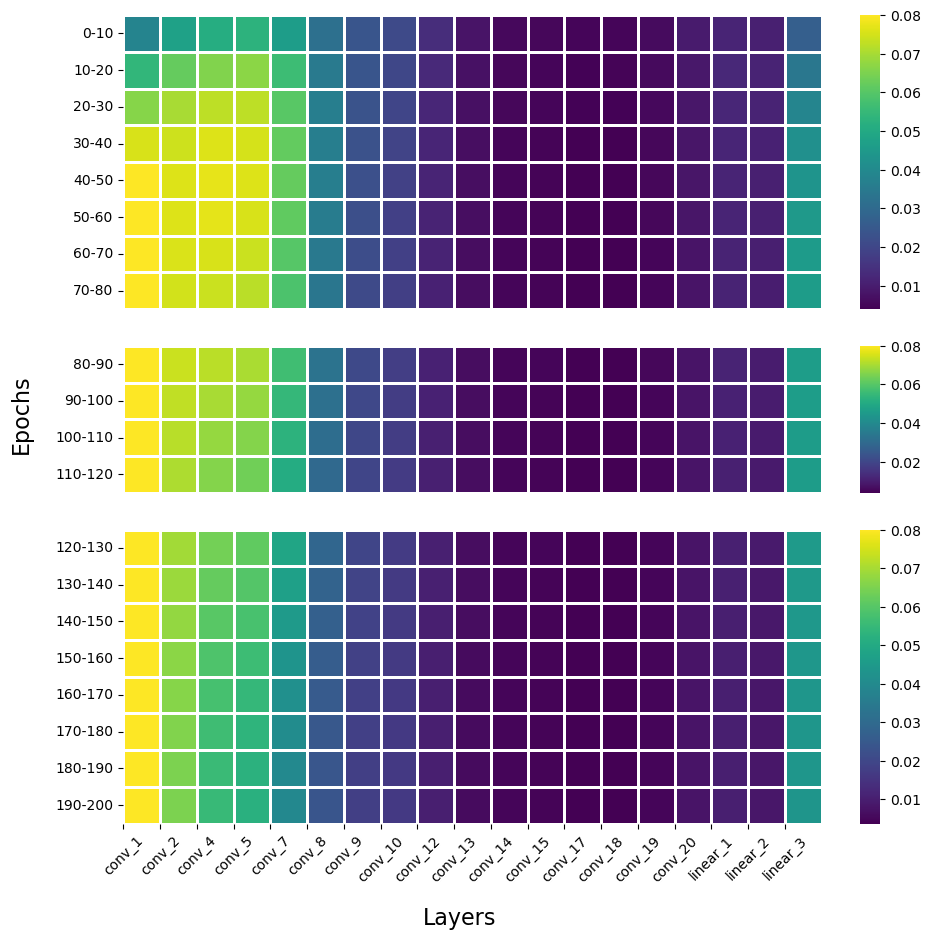

In [11]:
num_rows, num_cols = data.shape
row_labels = [
    f"{i*10}-{(i+1)*10}" for i in range(num_rows)
]
col_labels = label_names

# Split data into groups
groups = [
    (data[:8], row_labels[:8], 0.08),
    (data[8:12], row_labels[8:12], 0.08),
    (data[12:], row_labels[12:], 0.08),
]

fig, axes = plt.subplots(
    len(groups), 1,
    figsize=(10, 0.5*len(row_labels) + 0.5*len(groups) - 1),
    gridspec_kw={
        "height_ratios": [len(g[0]) for g in groups],
        "hspace": 0.15
    }
)

if len(groups) == 1:
    axes = [axes]

for i, (ax, (d, l, vmax)) in enumerate(zip(axes, groups)):
    print(d.shape, l)

    pos = ax.get_position()
    cbar_ax = fig.add_axes([
        pos.x1 - 0.00, pos.y0, 0.02, pos.height
    ])
    plot_epoch_layer_heatmap(
        d,
        ax=ax,
        layers=label_names,
        epochs=l,
        cbar=True,
        vmax=vmax,
        cbar_ax=cbar_ax,
        x_ticks=label_names if i == len(groups) - 1 else None,
    )

fig_w, fig_h = fig.get_size_inches()
fig.supxlabel("Layers", fontsize=16, y=0.1 / fig_h)
fig.supylabel("Epochs", fontsize=16, x=0.5 / fig_w)
plt.savefig(f"{fig_path}/weight_diffs_per_epoch.png")

## Isotropy

100%|██████████| 3/3 [06:54<00:00, 138.00s/it]


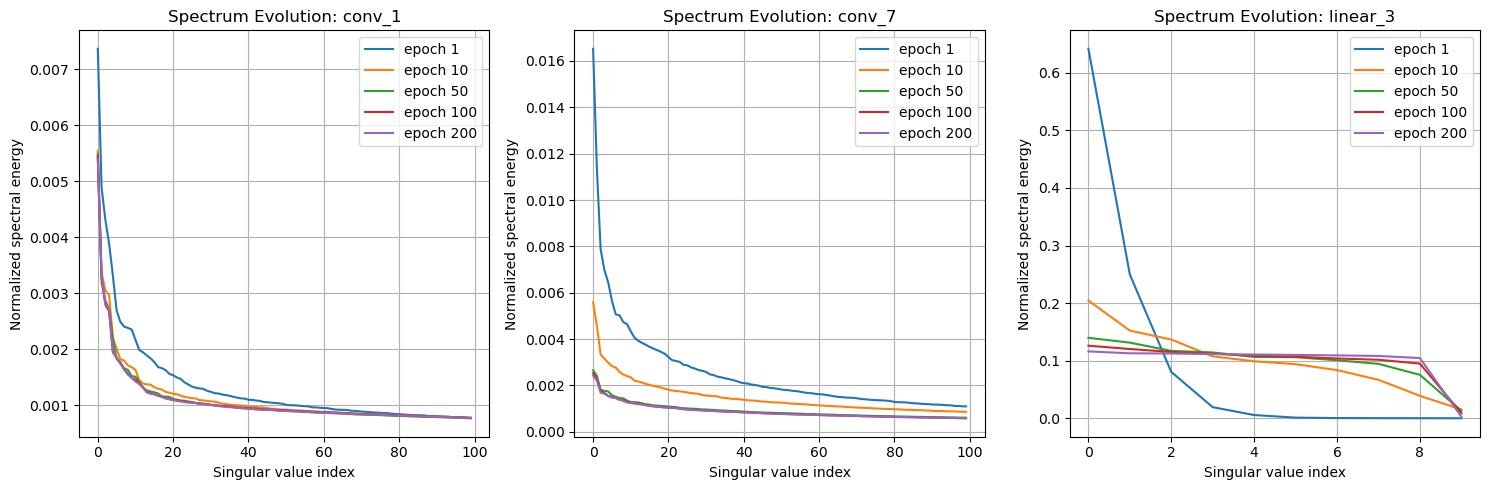

In [12]:
layer_ids = [0, tunnel_95, -1]
layers = [layer_names[i] for i in layer_ids]
singular_values = { layer: [] for layer in layers }
sv_min = float("inf")
sv_max = float("-inf")
epochs = [1, 10, 50, 100, num_epochs]
for id in tqdm(layer_ids):
    layer = layer_names[id]
    for epoch in epochs:
        feats = torch.load(os.path.join(result_path, "analysis", f"epoch{epoch}", "features", f"test_feats_{layer}.pt"), map_location='cpu')
        sv, _ = compute_energy(feats, device=device)
        # sv_min = min(sv_min, sv.min().item())
        # sv_max = max(sv_max, sv.max().item())
        singular_values[layer].append(sv[:100].cpu().numpy())
        del feats, sv
        if torch.cuda.is_available():
            torch.cuda.empty_cache()
        import gc
        gc.collect()

fig, axs = plt.subplots(1, 3, figsize=(15, 5))
for i, id in enumerate(layer_ids):
    for e, sv in zip(epochs, singular_values[layer_names[id]]):
        axs[i].plot(sv, label=f"epoch {e}")
        axs[i].set_xlabel("Singular value index")
        axs[i].set_ylabel("Normalized spectral energy")
        axs[i].set_title(f"Spectrum Evolution: {label_names[id]}")
        axs[i].legend(title="")
        # axs[i].set_yscale("log")
        axs[i].grid()
        # axs[i].set_ylim(np.log(sv_min), np.log(sv_max))
plt.tight_layout()
plt.savefig(f"{fig_path}/singular_value.png")

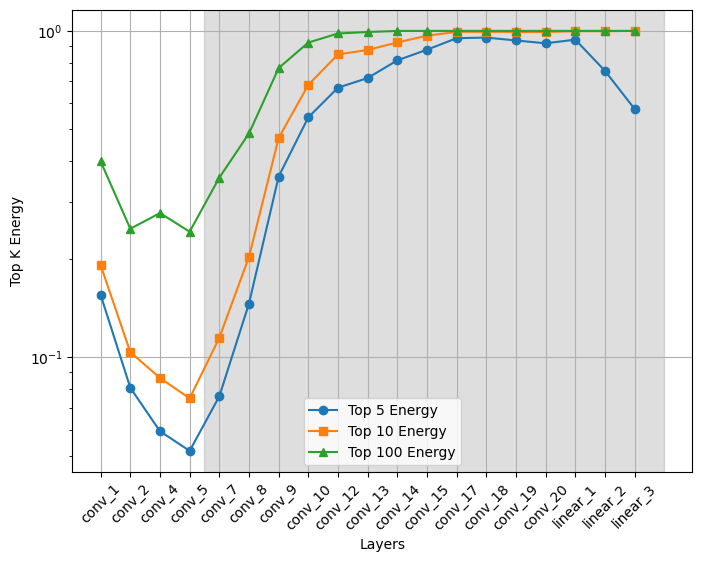

In [13]:
top_5_energy = []
top_10_energy = []
top_100_energy = []
for layer in layer_names:
    feats = torch.load(os.path.join(result_path, "analysis", f"epoch{num_epochs}", "features", f"test_feats_{layer}.pt"), map_location='cpu')
    feats[:100, :]
    sv, energy = compute_energy(feats, device=device)
    del feats

    top_5_energy.append(energy[:5].sum().item())
    top_10_energy.append(energy[:10].sum().item())
    top_100_energy.append(energy[:100].sum().item())

plt.figure(figsize=(8, 6))
plt.axvspan(tunnel_95 - 0.5, len(label_names), alpha=0.25, color="tab:gray")
plt.plot(top_5_energy, label="Top 5 Energy", marker='o')
plt.plot(top_10_energy, label="Top 10 Energy", marker='s')
plt.plot(top_100_energy, label="Top 100 Energy", marker='^')
plt.xlabel("Layers")
plt.ylabel("Top K Energy")
plt.xticks(range(len(label_names)), label_names)
plt.tick_params(axis="x", rotation=45)
plt.yscale("log")
plt.legend()
plt.grid()
plt.savefig(f"{fig_path}/topk_energy.png")
plt.show()